In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing, global_mean_pool, global_max_pool
from torch_geometric.utils import add_self_loops, softmax
from torch_geometric.data import Data, DataLoader
from torch_geometric.datasets import TUDataset
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from tqdm import tqdm
import random


# Your GNN implementation (fixed syntax issues)
class EdgeWeightGenerator(nn.Module):
    """First layer: learns initial edge weights from node pairs."""

    def __init__(self, in_dim, hidden_dim=64):
        super().__init__()
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * in_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1)
        )

    def forward(self, x, edge_index):
        src, dst = edge_index
        edge_feat = torch.cat([x[src], x[dst]], dim=-1)
        edge_weight = self.edge_mlp(edge_feat).squeeze(-1)  # [num_edges]
        # Normalize per source node (softmax like GAT)
        edge_weight = softmax(edge_weight, src)
        return edge_weight


class WeightedMessagePassing(MessagePassing):
    """Message passing layer that uses learned edge weights."""

    def __init__(self, in_dim, out_dim):
        super().__init__(aggr="add")
        self.node_mlp = nn.Sequential(
            nn.Linear(in_dim, out_dim), nn.ReLU(), nn.Linear(out_dim, out_dim)
        )

    def forward(self, x, edge_index, edge_weight):
        return self.propagate(edge_index, x=x, edge_weight=edge_weight)

    def message(self, x_j, edge_weight):
        return edge_weight.view(-1, 1) * self.node_mlp(x_j)


class EdgeWeightUpdater(nn.Module):
    """Recomputes new edge weights after some message passing."""

    def __init__(self, node_dim, hidden_dim=64):
        super().__init__()
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * node_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1)
        )

    def forward(self, x, edge_index):
        src, dst = edge_index
        edge_feat = torch.cat([x[src], x[dst]], dim=-1)
        new_weight = self.edge_mlp(edge_feat).squeeze(-1)
        # Normalize per source node
        new_weight = softmax(new_weight, src)
        return new_weight


class GraphEmbedder(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, emb_dim=128, add_self_loops_flag=True):
        super().__init__()
        self.edge_init = EdgeWeightGenerator(in_dim, hidden_dim)
        self.conv1 = WeightedMessagePassing(in_dim, hidden_dim)
        self.edge_updater = EdgeWeightUpdater(hidden_dim, hidden_dim)
        self.conv2 = WeightedMessagePassing(hidden_dim, hidden_dim)
        self.fc = nn.Linear(2 * hidden_dim, emb_dim)
        self.add_self_loops_flag = add_self_loops_flag

    def forward(self, x, edge_index, batch):
        num_nodes = x.size(0)
        # Optionally add self-loops
        if self.add_self_loops_flag:
            edge_index, _ = add_self_loops(edge_index, num_nodes=num_nodes)

        # 1. Generate initial edge weights
        edge_weight = self.edge_init(x, edge_index)

        # 2. First message passing
        x = F.relu(self.conv1(x, edge_index, edge_weight))

        # 3. Update edge weights
        edge_weight = self.edge_updater(x, edge_index)

        # 4. Second message passing with updated weights
        x = F.relu(self.conv2(x, edge_index, edge_weight))

        # 5. Pooling → fixed size embedding
        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=-1)

        return self.fc(x)


# Complete model for classification
class GNNClassifier(nn.Module):
    def __init__(self, in_dim, hidden_dim=20, emb_dim=16, num_classes=2):
        super().__init__()
        self.embedder = GraphEmbedder(in_dim, hidden_dim, emb_dim)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, emb_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(emb_dim // 2, num_classes),
        )

    def forward(self, x, edge_index, batch):
        emb = self.embedder(x, edge_index, batch)
        logits = self.classifier(emb)
        return torch.nn.functional.softmax(logits, dim=-1)


# Synthetic data generation
def create_synthetic_graph(num_nodes=20, num_features=5, edge_prob=0.3, label=None):
    """Create a synthetic graph with random features and structure."""
    x = torch.randn(num_nodes, num_features)

    # Create edges based on probability
    edge_list = []
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            if random.random() < edge_prob:
                edge_list.extend([(i, j), (j, i)])  # Undirected graph

    if not edge_list:  # Ensure at least one edge
        edge_list = [(0, 1), (1, 0)]

    edge_index = torch.tensor(edge_list).t().contiguous()

    # Random label if not provided
    y = torch.tensor([random.randint(0, 1) if label is None else label])

    return Data(x=x, edge_index=edge_index, y=y)


def create_synthetic_dataset(num_graphs=1000, **graph_kwargs):
    """Create a dataset of synthetic graphs."""
    graphs = []
    for i in range(num_graphs):
        # Create graphs with different characteristics for different classes
        if i < num_graphs // 2:
            # Class 0: smaller, less connected graphs
            graph = create_synthetic_graph(
                num_nodes=random.randint(10, 20),
                edge_prob=random.uniform(0.1, 0.3),
                label=0,
                **graph_kwargs,
            )
        else:
            # Class 1: larger, more connected graphs
            graph = create_synthetic_graph(
                num_nodes=random.randint(15, 30),
                edge_prob=random.uniform(0.3, 0.6),
                label=1,
                **graph_kwargs,
            )
        graphs.append(graph)

    return graphs


# Training function
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in tqdm(loader, desc="Training", leave=False):
        batch = batch.to(device)
        optimizer.zero_grad()

        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = out.argmax(dim=1)
        correct += (pred == batch.y).sum().item()
        total += batch.y.size(0)

    return total_loss / len(loader), correct / total


# Evaluation function
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y)

            total_loss += loss.item()
            pred = out.argmax(dim=1)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(batch.y.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader), accuracy, all_preds, all_labels


# Main training script
def main():
    # Set random seeds for reproducibility
    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)

    # Device configuration
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Hyperparameters
    num_features = 5
    hidden_dim = 20
    emb_dim = 16
    num_classes = 2
    batch_size = 32
    learning_rate = 0.001
    num_epochs = 50

    # Create synthetic dataset
    print("Creating synthetic dataset...")
    graphs = create_synthetic_dataset(num_graphs=10000, num_features=num_features)

    # Split dataset
    train_size = int(0.8 * len(graphs))
    val_size = int(0.1 * len(graphs))
    test_size = len(graphs) - train_size - val_size

    train_graphs = graphs[:train_size]
    val_graphs = graphs[train_size : train_size + val_size]
    test_graphs = graphs[train_size + val_size :]

    # Create data loaders
    train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_graphs, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_graphs, batch_size=batch_size, shuffle=False)

    print(
        f"Dataset split: {len(train_graphs)} train, {len(val_graphs)} val, {len(test_graphs)} test"
    )

    # Initialize model
    model = GNNClassifier(
        in_dim=num_features,
        hidden_dim=hidden_dim,
        emb_dim=emb_dim,
        num_classes=num_classes,
    ).to(device)

    # Print model info
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params}")
    print(f"Trainable parameters: {trainable_params}")

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=learning_rate, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )

    # Training loop
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []

    best_val_acc = 0
    patience = 10
    patience_counter = 0

    print("\nStarting training...")
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # Train
        train_loss, train_acc = train_epoch(
            model, train_loader, optimizer, criterion, device
        )

        # Validate
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

        # Update learning rate
        scheduler.step(val_loss)

        # Store metrics
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        print(f"Current LR: {optimizer.param_groups[0]['lr']:.6f}")

        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), "best_gnn_model.pth")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    # Load best model and test
    model.load_state_dict(torch.load("best_gnn_model.pth"))
    test_loss, test_acc, test_preds, test_labels = evaluate(
        model, test_loader, criterion, device
    )

    print(f"\nFinal Test Results:")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print("\nClassification Report:")
    print(
        classification_report(
            test_labels, test_preds, target_names=["Class 0", "Class 1"]
        )
    )

    # Plot training curves
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label="Train Acc")
    plt.plot(val_accs, label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

Using device: cpu
Creating synthetic dataset...


/Users/simi/mu3e_trigger/venv/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Dataset split: 8000 train, 1000 val, 1000 test
Total parameters: 3272
Trainable parameters: 3272

Starting training...

Epoch 1/50


Train Loss: 0.6137, Train Acc: 0.6645
Val Loss: 0.4696, Val Acc: 0.9380
Current LR: 0.001000

Epoch 2/50


Train Loss: 0.4380, Train Acc: 0.8866
Val Loss: 0.4239, Val Acc: 0.8880
Current LR: 0.001000

Epoch 3/50


...

Train Loss: 0.3901, Train Acc: 0.9261
Val Loss: 0.3964, Val Acc: 0.9130
Current LR: 0.001000

Epoch 10/50


Train Loss: 0.3845, Train Acc: 0.9299
Val Loss: 0.4165, Val Acc: 0.8960
Current LR: 0.001000

Epoch 11/50


Train Loss: 0.3805, Train Acc: 0.9296
Val Loss: 0.3882, Val Acc: 0.9230
Current LR: 0.000500

Early stopping at epoch 11


/Users/simi/mu3e_trigger/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/simi/mu3e_trigger/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/simi/mu3e_trigger/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Final Test Results:
Test Loss: 0.4828
Test Accuracy: 0.9200

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00         0
     Class 1       1.00      0.92      0.96      1000

    accuracy                           0.92      1000
   macro avg       0.50      0.46      0.48      1000
weighted avg       1.00      0.92      0.96      1000



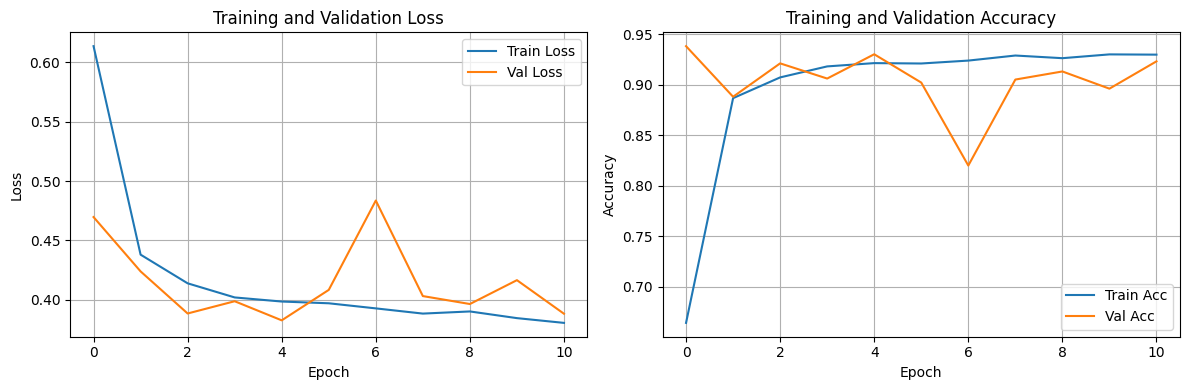

In [2]:
main()